In [ ]:
from datasets import load_dataset
import datasets

print("datasets version:", datasets.__version__)

# NewsMTSC on Hugging Face
ds_td = load_dataset("fhamborg/news_sentiment_newsmtsc")

print(ds_td)
print("Train example:", ds_td["train"][0])
print("Features:", ds_td["train"].features)

datasets version: 4.0.0


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

news_sentiment_newsmtsc.py: 0.00B [00:00, ?B/s]

RuntimeError: Dataset scripts are no longer supported, but found news_sentiment_newsmtsc.py

In [ ]:
from collections import Counter

# Look at a few examples
print(ds_td["train"][0])
print(ds_td["train"][1])

# What are the polarity values?
vals = ds_td["train"]["polarity"]
print("polarity type example:", type(vals[0]), vals[0])

print("Unique polarity values (train):", sorted(set(vals))[:50])
print("Train polarity distribution:", Counter(vals))

Build TD training datasets (sentence, mention → label) + tokenize

In [ ]:
import datasets
datasets.enable_progress_bar()

In [ ]:
from datasets import DatasetDict
from transformers import AutoTokenizer
import datasets

# Make sure progress bars are enabled
datasets.disable_caching()  # optional: avoids cache confusion in Colab
datasets.logging.set_verbosity_warning()

POL2ID = {-1: 0, 0: 1, 1: 2}
ID2LABEL = {0: "negative", 1: "neutral", 2: "positive"}
LABEL2ID = {v: k for k, v in ID2LABEL.items()}

def add_label(batch):
    batch["label"] = [POL2ID[p] for p in batch["polarity"]]
    return batch

print("1) Adding label column (progress bar should appear)...")
train_td = ds_td["train"].map(add_label, batched=True, desc="Add label (train)")

if "validation" in ds_td:
    val_td = ds_td["validation"].map(add_label, batched=True, desc="Add label (val)")
else:
    print("No validation split found; creating stratified split...")
    split = train_td.train_test_split(test_size=0.15, seed=42, stratify_by_column="label")
    train_td, val_td = split["train"], split["test"]

print("Train/Val sizes:", len(train_td), len(val_td))
print("Example:", train_td[0])

# Tokenizer
BASE_MODEL = "roberta-base"
MAX_LEN = 192
tokenizer_td = AutoTokenizer.from_pretrained(BASE_MODEL, use_fast=True)

def tokenize_td(batch):
    return tokenizer_td(
        batch["sentence"],
        batch["mention"],
        truncation=True,
        max_length=MAX_LEN,
    )

# Only keep label + tokenized fields
keep_cols = ["label", "input_ids", "attention_mask"]
def _remove_cols(ds):
    return [c for c in ds.column_names if c not in keep_cols]

print("\n2) Tokenizing TD pairs (sentence, mention) (progress bar should appear)...")
train_tok = train_td.map(
    tokenize_td,
    batched=True,
    remove_columns=_remove_cols(train_td),
    desc="Tokenize (train)",
)

val_tok = val_td.map(
    tokenize_td,
    batched=True,
    remove_columns=_remove_cols(val_td),
    desc="Tokenize (val)",
)

td_data = DatasetDict(train=train_tok, validation=val_tok)

print("\nDone.")
print(td_data)
print("Tokenized columns:", td_data["train"].column_names)
print("Label sample:", td_data["train"][0]["label"])

1) Adding label column (progress bar should appear)...


Add label (train):   0%|          | 0/8739 [00:00<?, ? examples/s]

Add label (val):   0%|          | 0/343 [00:00<?, ? examples/s]

Train/Val sizes: 8739 343
Example: {'mention': 'Winner', 'polarity': 0, 'from': 0, 'to': 6, 'sentence': 'Winner wrote that she had a 30-minute private meeting with the Republican lawmaker’s state policy director.', 'id': 'allsides_1000_401_25_Reality Leigh Winner_0_6', 'label': 1}


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]


2) Tokenizing TD pairs (sentence, mention) (progress bar should appear)...


Tokenize (train):   0%|          | 0/8739 [00:00<?, ? examples/s]

Tokenize (val):   0%|          | 0/343 [00:00<?, ? examples/s]


Done.
DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 8739
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 343
    })
})
Tokenized columns: ['label', 'input_ids', 'attention_mask']
Label sample: 1


Step 5: Training TD

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

from transformers import (
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed,
)

set_seed(42)

model_td = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

collator_td = DataCollatorWithPadding(tokenizer=tokenizer_td)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
    }

args_td = TrainingArguments(
    output_dir="/content/drive/MyDrive/NLP Final Project/td_roberta_newsmtsc/",
    seed=42,

    learning_rate=2e-5,
    num_train_epochs=3,

    per_device_train_batch_size=32,   # T4-safe
    per_device_eval_batch_size=64,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,

    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    fp16=True,
    weight_decay=0.01,
    warmup_ratio=0.06,

    save_total_limit=2,
    report_to=["none"],
    remove_unused_columns=False,
)

trainer_td = Trainer(
    model=model_td,
    args=args_td,
    train_dataset=td_data["train"],
    eval_dataset=td_data["validation"],
    data_collator=collator_td,
    compute_metrics=compute_metrics,
)

trainer_td.train()
metrics_td = trainer_td.evaluate()
print("TD Validation metrics:", metrics_td)

# Save model/tokenizer for later inference
SAVE_TD = "/content/drive/MyDrive/NLP Final Project/td_roberta_newsmtsc/best_model"
trainer_td.save_model(SAVE_TD)
tokenizer_td.save_pretrained(SAVE_TD)
print("Saved TD model to:", SAVE_TD)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.474997,0.389431,0.848397,0.834270,0.849327
2,0.346454,0.389764,0.860058,0.844890,0.858663
3,0.254439,0.391196,0.877551,0.861215,0.875906


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TD Validation metrics: {'eval_loss': 0.39119601249694824, 'eval_accuracy': 0.8775510204081632, 'eval_f1_macro': 0.8612148563128955, 'eval_f1_weighted': 0.8759057818138593, 'eval_runtime': 0.5913, 'eval_samples_per_second': 580.1, 'eval_steps_per_second': 10.148, 'epoch': 3.0}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved TD model to: /content/drive/MyDrive/NLP Final Project/td_roberta_newsmtsc/best_model


In [ ]:
import pandas as pd
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
ORG_CSV  = "/content/drive/MyDrive/NLP Final Project/Entity Extraction/top_orgs_by_topic_full_trf.csv"
TECH_CSV = "/content/drive/MyDrive/NLP Final Project/Entity Extraction/top_tech_by_topic_full_trf.csv"


org = pd.read_csv(ORG_CSV)
tech = pd.read_csv(TECH_CSV)

Mounted at /content/drive


In [ ]:
TOP_N = 30

# Remove topic -1
org_clean = org[org["topic"] != -1].copy()
tech_clean = tech[tech["topic"] != -1].copy()

# Aggregate counts
top_org = (
    org_clean
    .groupby("entity")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(TOP_N)
)

top_tech = (
    tech_clean
    .groupby("entity")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(TOP_N)
)

# Combine and deduplicate
targets = sorted(set(top_org.index.tolist() + top_tech.index.tolist()))

print("Total targets selected:", len(targets))
print("\nTop ORG:")
print(top_org.head(10))

print("\nTop TECH:")
print(top_tech.head(10))

print("\nCombined target sample:")
print(targets[:15])

Total targets selected: 54

Top ORG:
entity
OpenAI           68432
Google           53698
Microsoft        47096
LG               35291
Apple            32445
Nvidia           26126
ChatGPT          19379
Nasdaq           16680
Rawpixel Ltd.    13847
Samsung          13641
Name: count, dtype: int64

Top TECH:
entity
ChatGPT     131994
OpenAI       78686
Nvidia       28334
iPhone       27067
Gemini       19986
Android      16523
Bitcoin      12616
iOS          11914
AMD          11735
DeepSeek      9817
Name: count, dtype: int64

Combined target sample:
['AMD', 'AP', 'Alphabet', 'Amazon', 'Android', 'Apple', 'Apple Watch', 'Bard', 'Bitcoin', 'Blockchain', 'CNA', 'ChatGPT', 'Claude', 'Copilot', 'Cryptocurrency']


Generate Sentences

In [ ]:
NEWS_PATH = "/content/drive/MyDrive/NLP Final Project/docs_with_topics.parquet"
df_news = pd.read_parquet(NEWS_PATH)


In [ ]:
df_news.head(2)

,url,date,title,clean_text,topic,topic_name
0,https://blockworks.co/price/bad,2025-06-23,"Bad Idea AI Price (BAD), Market Cap, Price Tod...","Bad Idea AI Price (BAD), Market Cap, Price Tod...",68,None
1,https://citylife.capetown/gl/uncategorized/the...,2023-11-10,The Road Ahead: How China's AI Foundation Mode...,The Road Ahead: How China's AI Foundation Mode...,-1,Outliers


In [ ]:
import re
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from tqdm.auto import tqdm
from pathlib import Path

OUT_PATH = Path("/content/drive/MyDrive/NLP Final Project/news_sentences.parquet")
if OUT_PATH.exists():
    OUT_PATH.unlink()  # overwrite

_SENT_SPLIT = re.compile(r"(?<=[.!?])\s+")

def split_sentences(text: str):
    if not isinstance(text, str) or not text.strip():
        return []
    return _SENT_SPLIT.split(text.strip())

writer = None
DOC_BATCH = 4000  # adjust if you want; smaller = less RAM

required_cols = ["date", "title", "clean_text", "topic", "topic_name"]
missing = [c for c in required_cols if c not in df_news.columns]
if missing:
    raise ValueError(f"df_news missing columns: {missing}")

n = len(df_news)
print("Docs:", n)

for start in tqdm(range(0, n, DOC_BATCH), desc="Sentence splitting (docs)"):
    chunk = df_news.iloc[start:start+DOC_BATCH][required_cols].copy()

    rows = []
    for doc_id, row in chunk.iterrows():
        text = f"{row['title']}. {row['clean_text']}"
        sents = split_sentences(text)
        sents = [s for s in sents if len(s) >= 25]  # drop tiny fragments

        for j, s in enumerate(sents):
            rows.append({
                "doc_id": int(doc_id),
                "date": row["date"],
                "topic": row["topic"],
                "topic_name": row["topic_name"],
                "sent_id": j,
                "sentence": s
            })

    if not rows:
        continue

    table = pa.Table.from_pandas(pd.DataFrame(rows), preserve_index=False)

    if writer is None:
        writer = pq.ParquetWriter(str(OUT_PATH), table.schema, compression="snappy")
    writer.write_table(table)

if writer is not None:
    writer.close()

print("Wrote:", OUT_PATH)

Docs: 183369


Sentence splitting (docs):   0%|          | 0/46 [00:00<?, ?it/s]

Wrote: /content/drive/MyDrive/NLP Final Project/news_sentences.parquet


In [ ]:
import pandas as pd
sent_df = pd.read_parquet("/content/drive/MyDrive/NLP Final Project/news_sentences.parquet")
print("Sentence rows:", sent_df.shape)
sent_df.head(3)

Sentence rows: (4259789, 6)


,doc_id,date,topic,topic_name,sent_id,sentence
0,0,2025-06-23,68,None,0,"Bad Idea AI Price (BAD), Market Cap, Price Tod..."
1,0,2025-06-23,68,None,1,"Bad Idea AI Price (BAD), Market Cap, Price Tod..."
2,0,2025-06-23,68,None,2,The table above accurately updates our BAD pri...


In [ ]:
!pip install flashtext

  Preparing metadata (setup.py) ... done
  Created wheel for flashtext: filename=flashtext-2.7-py2.py3-none-any.whl size=9300 sha256=985e045a605c3d9e029b9828a24c3ca78578eeb5e029490f5d972d79a6c92986
  Stored in directory: /root/.cache/pip/wheels/8c/24/da/4d994d7a27cfc73a4e513a669fbeec4a71f871fe245a81977f
Successfully built flashtext


In [ ]:
import numpy as np
import pandas as pd
import torch
import pyarrow.parquet as pq
from collections import defaultdict
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from flashtext import KeywordProcessor

# ---------- Targets ----------
TOP_N = 30
org_clean = org[org["topic"] != -1]
tech_clean = tech[tech["topic"] != -1]

top_org = org_clean.groupby("entity")["count"].sum().sort_values(ascending=False).head(TOP_N)
top_tech = tech_clean.groupby("entity")["count"].sum().sort_values(ascending=False).head(TOP_N)

targets = sorted(set(top_org.index.tolist() + top_tech.index.tolist()))
print("Targets:", len(targets))
print("Top ORG sample:", top_org.head(5).to_dict())
print("Top TECH sample:", top_tech.head(5).to_dict())

# FlashText processors
kp = KeywordProcessor(case_sensitive=False)

# Add all targets as keywords; return canonical casing
for t in targets:
    kp.add_keyword(t, t)  # (keyword, clean_name)

# Optional: anchor prefilter processor (even faster)
anchors = ["ChatGPT", "OpenAI", "Google", "Microsoft", "Nvidia", "Apple", "Samsung", "Android", "iPhone", "Gemini", "AMD", "Nasdaq"]
kp_anchor = KeywordProcessor(case_sensitive=False)
for a in anchors:
    kp_anchor.add_keyword(a, a)

# ---------- Load TD model ----------
TD_MODEL_DIR = "/content/drive/MyDrive/NLP Final Project/td_roberta_newsmtsc/best_model"
tokenizer_td_inf = AutoTokenizer.from_pretrained(TD_MODEL_DIR, use_fast=True)
model_td_inf = AutoModelForSequenceClassification.from_pretrained(TD_MODEL_DIR)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_td_inf.to(device)
model_td_inf.eval()
print("TD model on:", device)

def td_predict(pairs_sent, pairs_tgt):
    enc = tokenizer_td_inf(
        pairs_sent,
        pairs_tgt,
        truncation=True,
        max_length=192,
        padding=True,
        return_tensors="pt",
    )
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        probs = torch.softmax(model_td_inf(**enc).logits, dim=-1).detach().cpu().numpy().astype(np.float32)
    score = probs[:, 2] - probs[:, 0]
    return probs, score

# ---------- Stream parquet ----------
SENT_PATH = "/content/drive/MyDrive/NLP Final Project/news_sentences.parquet"
pf = pq.ParquetFile(SENT_PATH)
total_rows = pf.metadata.num_rows
print("Total sentence rows:", total_rows)

ROW_BATCH = 80_000   # FlashText is fast; we can increase batch size
PAIR_BATCH = 512     # fewer GPU calls

ent_count = defaultdict(int)
ent_sum_score = defaultdict(float)
ent_sum_pos = defaultdict(float)
ent_sum_neu = defaultdict(float)
ent_sum_neg = defaultdict(float)

ent_topic_count = defaultdict(int)
ent_topic_sum_score = defaultdict(float)

pair_sent, pair_tgt, pair_topic, pair_topic_name = [], [], [], []

num_batches = (total_rows // ROW_BATCH) + 1

for batch in tqdm(
    pf.iter_batches(batch_size=ROW_BATCH, columns=["topic","topic_name","sentence"]),
    total=num_batches,
    desc="Streaming sentences (FlashText)"
):
    dfb = batch.to_pandas()

    # Fast anchor prefilter (optional but recommended)
    # Keep sentences where at least one anchor appears
    # This is much cheaper than running full kp on everything
    mask = dfb["sentence"].apply(lambda s: len(kp_anchor.extract_keywords(s)) > 0)
    if not mask.any():
        continue
    dfm = dfb.loc[mask].copy()

    # Extract targets with FlashText
    dfm["targets"] = dfm["sentence"].apply(lambda s: list(dict.fromkeys(kp.extract_keywords(s))))
    dfm = dfm[dfm["targets"].map(len) > 0]
    if dfm.empty:
        continue

    for row in dfm.itertuples(index=False):
        topic_id = int(row.topic) if row.topic is not None else -999
        topic_nm = row.topic_name if row.topic_name is not None else None

        for t in row.targets:
            pair_sent.append(row.sentence)
            pair_tgt.append(t)
            pair_topic.append(topic_id)
            pair_topic_name.append(topic_nm)

        if len(pair_sent) >= PAIR_BATCH:
            probs, score = td_predict(pair_sent, pair_tgt)

            for i in range(len(pair_sent)):
                e = pair_tgt[i]
                ent_count[e] += 1
                ent_sum_neg[e] += float(probs[i, 0])
                ent_sum_neu[e] += float(probs[i, 1])
                ent_sum_pos[e] += float(probs[i, 2])
                ent_sum_score[e] += float(score[i])

                key = (e, pair_topic[i], pair_topic_name[i])
                ent_topic_count[key] += 1
                ent_topic_sum_score[key] += float(score[i])

            pair_sent.clear(); pair_tgt.clear(); pair_topic.clear(); pair_topic_name.clear()

# Flush remainder
if pair_sent:
    probs, score = td_predict(pair_sent, pair_tgt)
    for i in range(len(pair_sent)):
        e = pair_tgt[i]
        ent_count[e] += 1
        ent_sum_neg[e] += float(probs[i, 0])
        ent_sum_neu[e] += float(probs[i, 1])
        ent_sum_pos[e] += float(probs[i, 2])
        ent_sum_score[e] += float(score[i])

        key = (e, pair_topic[i], pair_topic_name[i])
        ent_topic_count[key] += 1
        ent_topic_sum_score[key] += float(score[i])

# ---------- Build outputs ----------
entity_td_summary = pd.DataFrame({
    "entity": list(ent_count.keys()),
    "n_mentions": [ent_count[e] for e in ent_count.keys()],
    "mean_prob_negative": [ent_sum_neg[e] / ent_count[e] for e in ent_count.keys()],
    "mean_prob_neutral":  [ent_sum_neu[e] / ent_count[e] for e in ent_count.keys()],
    "mean_prob_positive": [ent_sum_pos[e] / ent_count[e] for e in ent_count.keys()],
    "mean_td_score":      [ent_sum_score[e] / ent_count[e] for e in ent_count.keys()],
}).sort_values(["n_mentions", "mean_td_score"], ascending=[False, False])

entity_topic_td_summary = pd.DataFrame(
    [(e, topic, topic_nm,
      ent_topic_count[(e, topic, topic_nm)],
      ent_topic_sum_score[(e, topic, topic_nm)] / ent_topic_count[(e, topic, topic_nm)])
     for (e, topic, topic_nm) in ent_topic_count.keys()],
    columns=["entity", "topic", "topic_name", "n_mentions", "mean_td_score"]
)

print("entity_td_summary:", entity_td_summary.shape)
print("entity_topic_td_summary:", entity_topic_td_summary.shape)

entity_td_summary.head(15)

Targets: 54
Top ORG sample: {'OpenAI': 68432, 'Google': 53698, 'Microsoft': 47096, 'LG': 35291, 'Apple': 32445}
Top TECH sample: {'ChatGPT': 131994, 'OpenAI': 78686, 'Nvidia': 28334, 'iPhone': 27067, 'Gemini': 19986}


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

TD model on: cuda
Total sentence rows: 4259789


Streaming sentences (FlashText):   0%|          | 0/54 [00:00<?, ?it/s]

entity_td_summary: (50, 6)
entity_topic_td_summary: (4713, 5)


,entity,n_mentions,mean_prob_negative,mean_prob_neutral,mean_prob_positive,mean_td_score
3,ChatGPT,158189,0.157593,0.425551,0.416856,0.259264
2,OpenAI,134434,0.124832,0.407984,0.467184,0.342351
0,Google,128712,0.116947,0.568162,0.314891,0.197945
7,Microsoft,89593,0.145217,0.498568,0.356215,0.210998
10,Nvidia,56364,0.107058,0.440246,0.452696,0.345638
8,Apple,51215,0.126244,0.646669,0.227087,0.100843
9,Nasdaq,38391,0.009636,0.932339,0.058026,0.048390
15,Android,22595,0.017537,0.909340,0.073123,0.055586
27,iPhone,20959,0.043648,0.861810,0.094543,0.050895
4,Gemini,20492,0.089049,0.409319,0.501632,0.412582


In [ ]:
import pandas as pd
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
entity_td_summary = pd.read_parquet("/content/drive/MyDrive/NLP Final Project/entity_td_summary.parquet")

Mounted at /content/drive


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/NLP Final Project/entity_td_summary.parquet'

In [5]:
entity_td_summary

,entity,n_mentions,mean_prob_negative,mean_prob_neutral,mean_prob_positive,mean_td_score
3,ChatGPT,158189,0.157593,0.425551,0.416856,0.259264
2,OpenAI,134434,0.124832,0.407984,0.467184,0.342351
0,Google,128712,0.116947,0.568162,0.314891,0.197945
7,Microsoft,89593,0.145217,0.498568,0.356215,0.210998
10,Nvidia,56364,0.107058,0.440246,0.452696,0.345638
8,Apple,51215,0.126244,0.646669,0.227087,0.100843
9,Nasdaq,38391,0.009636,0.932339,0.058026,0.048390
15,Android,22595,0.017537,0.909340,0.073123,0.055586
27,iPhone,20959,0.043648,0.861810,0.094543,0.050895
4,Gemini,20492,0.089049,0.409319,0.501632,0.412582


In [6]:
import numpy as np

entity_td_summary["td_weighted"] = (
    entity_td_summary["mean_td_score"] *
    np.log1p(entity_td_summary["n_mentions"])
)

In [7]:
entity_td_summary["tone_intensity"] = 1 - entity_td_summary["mean_prob_neutral"]

In [8]:
# Most positively framed
entity_td_summary.sort_values("mean_td_score", ascending=False).head(15)

# Most negatively framed
entity_td_summary.sort_values("mean_td_score").head(15)

# Most polarized
entity_td_summary.sort_values("tone_intensity", ascending=False).head(15)

,entity,n_mentions,mean_prob_negative,mean_prob_neutral,mean_prob_positive,mean_td_score,td_weighted,tone_intensity
49,Smart Portfolio,1,0.007635,0.009061,0.983304,0.975669,0.676282,0.990939
22,Copilot,9926,0.091826,0.402914,0.505260,0.413435,3.804844,0.597086
34,DeepSeek,4199,0.163142,0.405989,0.430869,0.267727,2.233606,0.594011
2,OpenAI,134434,0.124832,0.407984,0.467184,0.342351,4.042769,0.592016
4,Gemini,20492,0.089049,0.409319,0.501632,0.412582,4.096051,0.590681
3,ChatGPT,158189,0.157593,0.425551,0.416856,0.259264,3.103790,0.574449
10,Nvidia,56364,0.107058,0.440246,0.452696,0.345638,3.781141,0.559754
26,Claude,3747,0.062560,0.446741,0.490699,0.428139,3.523150,0.553259
1,Bard,11432,0.135869,0.465876,0.398255,0.262386,2.451799,0.534124
43,Siri,3900,0.156323,0.488615,0.355063,0.198740,1.643379,0.511385


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 20 by mentions
top_entities = (
    entity_td_summary
    .sort_values("n_mentions", ascending=False)
    .head(20)
    .sort_values("mean_td_score")
)

plt.figure(figsize=(10,8))

colors = ["#d62728" if x < 0 else "#2ca02c" for x in top_entities["mean_td_score"]]

plt.barh(
    top_entities["entity"],
    top_entities["mean_td_score"],
    color=colorshttps://accounts.google.com/SignOutOptions?hl=en&continue=https://colab.research.google.com/drive/1iXDD4PB0iZzUEc3-RgKPyb4bqQRXig1d&ec=GBRAqQM
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Entity Tone Differential (Positive − Negative)")
plt.xlabel("Mean TD Score")
plt.tight_layout()
plt.show()

SyntaxError: invalid decimal literal (606898624.py, line 19)

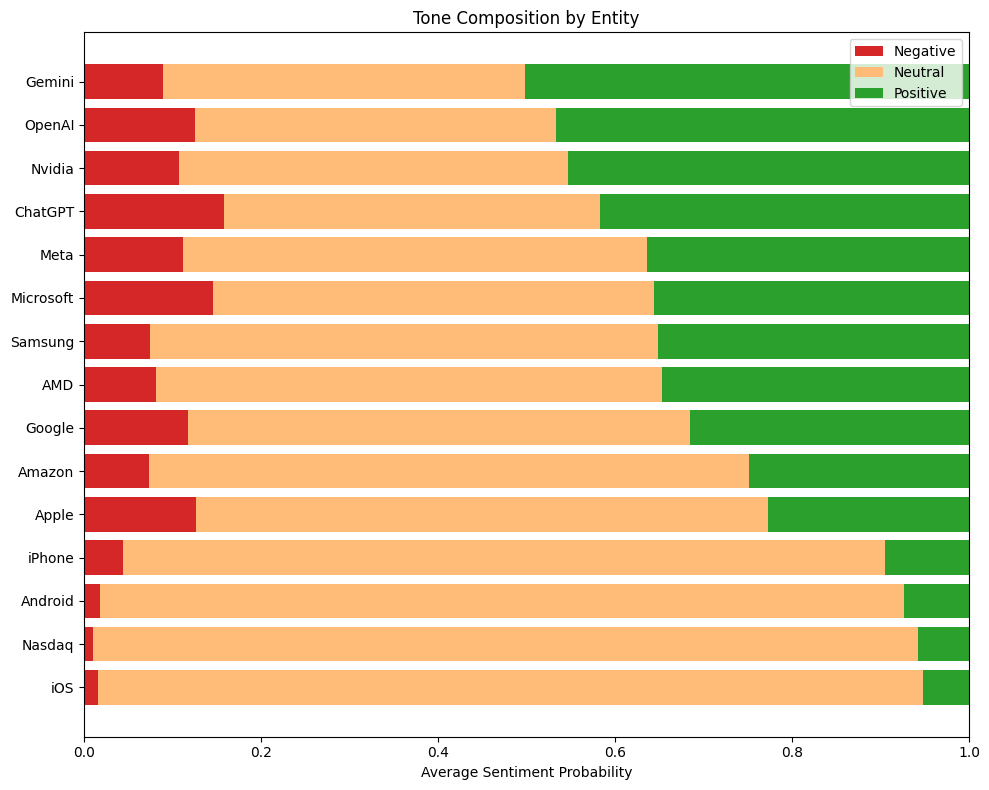

In [13]:

top_entities = (
    entity_td_summary
    .sort_values("n_mentions", ascending=False)
    .head(15)
    .sort_values("mean_prob_positive")
)

plt.figure(figsize=(10,8))

neg = top_entities["mean_prob_negative"]
neu = top_entities["mean_prob_neutral"]
pos = top_entities["mean_prob_positive"]

plt.barh(top_entities["entity"], neg, color="#d62728", label="Negative")
plt.barh(top_entities["entity"], neu, left=neg, color="#ffbb78", label="Neutral")
plt.barh(top_entities["entity"], pos, left=neg+neu, color="#2ca02c", label="Positive")

plt.xlim(0,1)
plt.title("Tone Composition by Entity")
plt.xlabel("Average Sentiment Probability")
plt.legend()
plt.tight_layout()
plt.show()

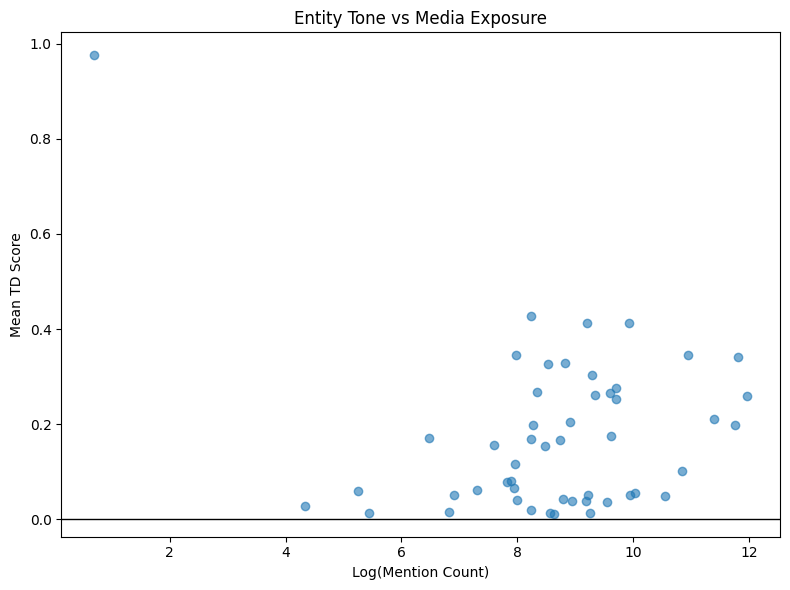

In [14]:
import numpy as np

plt.figure(figsize=(8,6))

plt.scatter(
    np.log1p(entity_td_summary["n_mentions"]),
    entity_td_summary["mean_td_score"],
    alpha=0.6
)

plt.axhline(0, color="black", linewidth=1)

plt.xlabel("Log(Mention Count)")
plt.ylabel("Mean TD Score")
plt.title("Entity Tone vs Media Exposure")

plt.tight_layout()
plt.show()

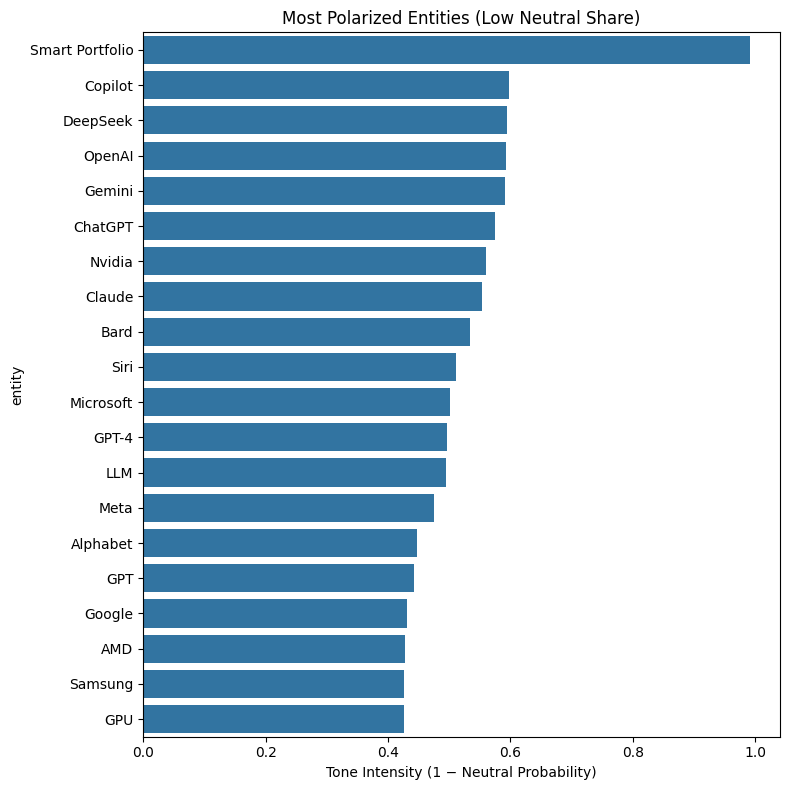

In [15]:
top_intensity = (
    entity_td_summary
    .sort_values("tone_intensity", ascending=False)
    .head(20)
)

plt.figure(figsize=(8,8))
sns.barplot(
    data=top_intensity,
    y="entity",
    x="tone_intensity"
)

plt.title("Most Polarized Entities (Low Neutral Share)")
plt.xlabel("Tone Intensity (1 − Neutral Probability)")
plt.tight_layout()
plt.show()

In [16]:
print(entity_td_summary["entity"].nunique())
print(entity_td_summary.head())

50
       entity  n_mentions  mean_prob_negative  mean_prob_neutral  \
3     ChatGPT      158189            0.157593           0.425551   
2      OpenAI      134434            0.124832           0.407984   
0      Google      128712            0.116947           0.568162   
7   Microsoft       89593            0.145217           0.498568   
10     Nvidia       56364            0.107058           0.440246   

    mean_prob_positive  mean_td_score  td_weighted  tone_intensity  
3             0.416856       0.259264     3.103790        0.574449  
2             0.467184       0.342351     4.042769        0.592016  
0             0.314891       0.197945     2.328888        0.431838  
7             0.356215       0.210998     2.406022        0.501432  
10            0.452696       0.345638     3.781141        0.559754  


In [17]:
# Create lookup sets
org_set = set(top_org.index)
tech_set = set(top_tech.index)

def classify_entity(e):
    if e in org_set:
        return "ORG"
    elif e in tech_set:
        return "TECH"
    else:
        return "OTHER"

entity_td_summary["entity_type"] = entity_td_summary["entity"].apply(classify_entity)

# Keep only ORG + TECH
entity_td_summary = entity_td_summary[
    entity_td_summary["entity_type"].isin(["ORG","TECH"])
]

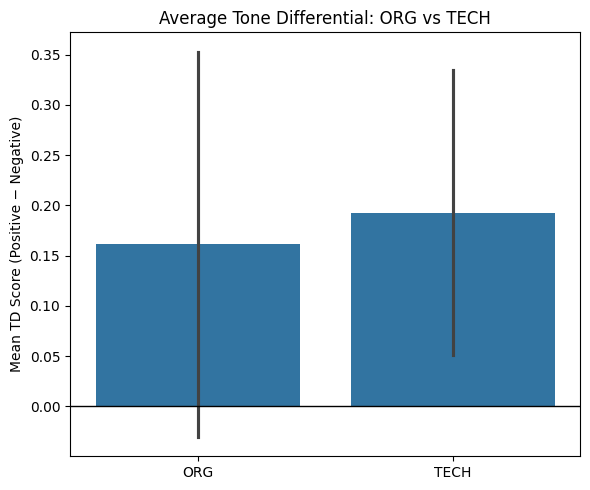

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.barplot(
    data=entity_td_summary,
    x="entity_type",
    y="mean_td_score",
    estimator="mean",
    errorbar="sd"
)

plt.axhline(0, color="black", linewidth=1)
plt.title("Average Tone Differential: ORG vs TECH")
plt.ylabel("Mean TD Score (Positive − Negative)")
plt.xlabel("")
plt.tight_layout()
plt.show()

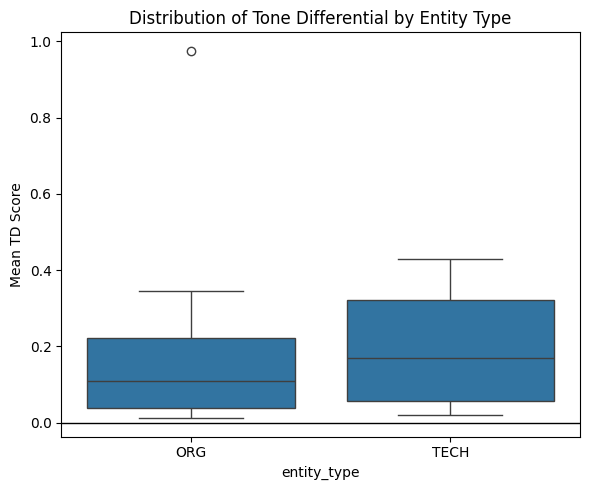

In [19]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=entity_td_summary,
    x="entity_type",
    y="mean_td_score"
)

plt.axhline(0, color="black", linewidth=1)
plt.title("Distribution of Tone Differential by Entity Type")
plt.ylabel("Mean TD Score")
plt.tight_layout()
plt.show()

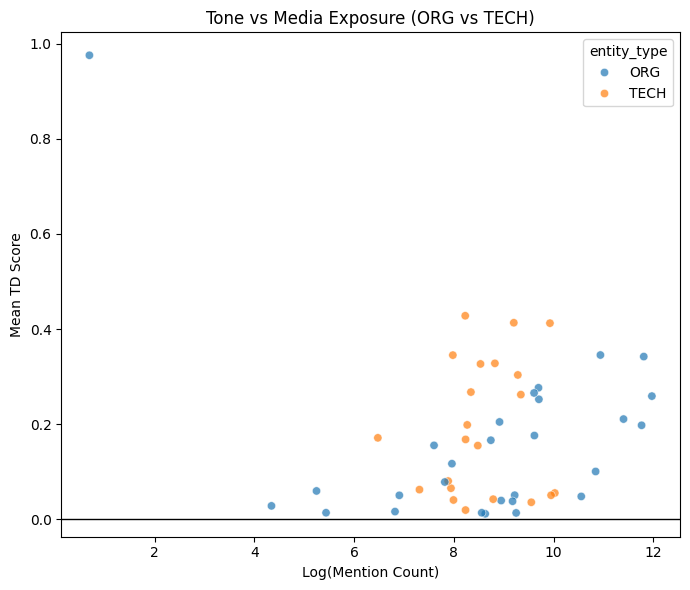

In [20]:
import numpy as np

plt.figure(figsize=(7,6))

sns.scatterplot(
    data=entity_td_summary,
    x=np.log1p(entity_td_summary["n_mentions"]),
    y="mean_td_score",
    hue="entity_type",
    alpha=0.7
)

plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Log(Mention Count)")
plt.ylabel("Mean TD Score")
plt.title("Tone vs Media Exposure (ORG vs TECH)")
plt.tight_layout()
plt.show()

In [ ]:
ENTITY_TOPIC_SAVE_PATH = "/content/drive/MyDrive/NLP Final Project/entity_topic_td_summary.parquet"

entity_topic_td_summary.to_parquet(ENTITY_TOPIC_SAVE_PATH, index=False)

print("Saved:", ENTITY_TOPIC_SAVE_PATH)

Saved: /content/drive/MyDrive/NLP Final Project/entity_topic_td_summary.parquet


In [ ]:
import json

TARGET_SAVE_PATH = "/content/drive/MyDrive/NLP Final Project/td_targets.json"

with open(TARGET_SAVE_PATH, "w") as f:
    json.dump(targets, f)

print("Saved targets:", TARGET_SAVE_PATH)

Saved targets: /content/drive/MyDrive/NLP Final Project/td_targets.json
